In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import numpy as np
import cv2
from pathlib import Path
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import time
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import warnings
import random
from PIL import Image
warnings.filterwarnings('ignore')


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class VideoFramesDataset(Dataset):
    def __init__(self, root_dir, split='train', frames_per_video=32, frame_size=224,
                 max_real=None, max_fake=None, seed=42):
        self.root_dir = Path(root_dir)
        self.split = split
        self.frames_per_video = frames_per_video
        self.frame_size = frame_size
        
        self.rng = random.Random(seed) if split != 'train' else random
        
        if split == 'train':
            self.base_dir = self.root_dir / 'trainframesfaces'
        elif split == 'val':
            self.base_dir = self.root_dir / 'valframesfaces'
        else:
            self.base_dir = self.root_dir / 'testframesfaces'
        
        self.fake_dir = self.base_dir / 'fake_frames_faces'
        self.real_dir = self.base_dir / 'real_frames_faces'
        
        fake_paths = sorted([f for f in self.fake_dir.iterdir() if f.is_dir()]) if self.fake_dir.exists() else []
        real_paths = sorted([f for f in self.real_dir.iterdir() if f.is_dir()]) if self.real_dir.exists() else []
            
        print(f"Found {len(fake_paths)} fake videos in {split}")
        print(f"Found {len(real_paths)} real videos in {split}")

        if max_real is not None:
            real_paths = self.rng.sample(real_paths, min(len(real_paths), max_real))
        if max_fake is not None:
            fake_paths = self.rng.sample(fake_paths, min(len(fake_paths), max_fake))
            
        print(f"После фильтрации: {len(real_paths)} real, {len(fake_paths)} fake")

        combined = list(zip(fake_paths + real_paths, [1]*len(fake_paths) + [0]*len(real_paths)))
        self.rng.shuffle(combined)
        self.video_paths, self.labels = zip(*combined)
        self.video_paths = list(self.video_paths)
        self.labels = list(self.labels)
        
        print(f" Total {len(self.video_paths)} videos for {split} split")
        print(f" Real (0): {self.labels.count(0)}")
        print(f" Fake (1): {self.labels.count(1)}")

        if self.split == 'train':
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(self.frame_size, scale=(0.8, 1.0), ratio=(0.9, 1.1)), 
                transforms.RandomHorizontalFlip(p=0.5),                                            
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),     
                transforms.RandomApply(
                    [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.5              
                ),
                transforms.RandomGrayscale(p=0.1),
                transforms.ToTensor(),
                transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize(self.frame_size + 32),
                transforms.CenterCrop(self.frame_size),
                transforms.ToTensor(),
                transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
            ])

    def __len__(self):
        return len(self.video_paths)
    
    def load_frames(self, video_path):
        frames = []
        frame_files = sorted([f for f in video_path.glob('*.jpg')])
        
        if len(frame_files) > self.frames_per_video:
            indices = np.linspace(0, len(frame_files)-1, self.frames_per_video, dtype=int)
            frame_files = [frame_files[i] for i in indices]
         
        for frame_file in frame_files:
            try:
                img = Image.open(frame_file).convert('RGB')
            except Exception:
                img = Image.new('RGB', (self.frame_size, self.frame_size))
            frames.append(img)

        if len(frames) > 0:
            orig_len = len(frames)
            while len(frames) < self.frames_per_video:
                frames.append(frames[len(frames) % orig_len])
        else:
            while len(frames) < self.frames_per_video:
                frames.append(Image.new('RGB', (self.frame_size, self.frame_size)))
        
        return frames
    
    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]
        frames = self.load_frames(video_path)
        
        transformed_frames = [self.transform(frame) for frame in frames]
        frames_tensor = torch.stack(transformed_frames)
        
        return frames_tensor, torch.tensor(label, dtype=torch.long)

def create_dataloaders(root_dir, batch_size=4, num_workers=2, frames_per_video=16, val_max_real=None, val_max_fake=None, test_max_real=None, test_max_fake=None):
    
    train_dataset = VideoFramesDataset(root_dir=root_dir, split='train', frames_per_video=frames_per_video)
    val_dataset = VideoFramesDataset(root_dir=root_dir, split='val', frames_per_video=frames_per_video, max_real=val_max_real, max_fake=val_max_fake)
    test_dataset = VideoFramesDataset(root_dir=root_dir, split='test', frames_per_video=frames_per_video, max_real=test_max_real, max_fake=test_max_fake)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=num_workers > 0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True, persistent_workers=num_workers > 0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True, persistent_workers=num_workers > 0)
    
    return train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset

In [8]:
class ResNetLSTM(nn.Module):
    def __init__(self, lstm_hidden=256, lstm_layers=2, dropout=0.5, freeze_cnn=True):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])
        self.cnn_out_dim = 2048  
        
        if freeze_cnn:
            for param in self.cnn.parameters():
                param.requires_grad = False
        
        self.lstm = nn.LSTM(
            input_size=self.cnn_out_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if lstm_layers > 1 else 0
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        batch_size, frames, C, H, W = x.shape
        cnn_out = []
        for t in range(frames):
            frame = x[:, t, :, :, :]   
            feat = self.cnn(frame)      
            feat = feat.view(batch_size, -1)  
            cnn_out.append(feat)
        cnn_seq = torch.stack(cnn_out, dim=1)  
        
        lstm_out, _ = self.lstm(cnn_seq)      
        last_out = lstm_out[:, -1, :]      
        logits = self.classifier(last_out)
        return logits


In [5]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    for frames, labels in tqdm(loader, desc='Train'):
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(frames)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return running_loss / len(loader), acc


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for frames, labels in tqdm(loader, desc='Val'):
            frames, labels = frames.to(device), labels.to(device)
            logits = model(frames)
            loss = criterion(logits, labels)
            running_loss += loss.item()
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return running_loss / len(loader), acc, f1, auc

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")
    
ROOT_DIR = "/kaggle/input/datasets/mariaspasyuk"
EPOCHS_FIRST = 10      
EPOCHS_FINETUNE = 10    
LR_FROZEN = 0.00001
train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = create_dataloaders(root_dir=ROOT_DIR, batch_size=32, num_workers=2, frames_per_video=16,
                                                                                                     val_max_real=None, val_max_fake=200, test_max_real=None, test_max_fake=N)

In [23]:
!rm -rf /kaggle/working/*

In [ ]:
import os
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
tb_writer = SummaryWriter(log_dir='runs/frozen_cnn')

model = ResNetLSTM(freeze_cnn=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_FROZEN)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
    
best_val_auc = 0.0
print("Frozen CNN")
train_loss_0, train_acc_0 = [], []
val_loss_0, val_acc_0, val_f1_0, val_auc_0 = [], [], [], []

for epoch in range(EPOCHS_FIRST):
    torch.cuda.empty_cache()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, val_auc = validate_epoch(model, val_loader, criterion, device)
    
    train_loss_0.append(round(train_loss, 4)); train_acc_0.append(round(train_acc, 4))
    val_loss_0.append(round(val_loss, 4)); val_acc_0.append(round(val_acc, 4))
    val_f1_0.append(round(val_f1, 4)); val_auc_0.append(round(val_auc, 4))
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    tb_writer.add_scalar('Stage1/Loss/Train', train_loss, epoch+1)
    tb_writer.add_scalar('Stage1/Accuracy/Train', train_acc, epoch+1)
    tb_writer.add_scalar('Stage1/Learning_Rate', current_lr, epoch+1)
    tb_writer.add_scalar('Stage1/Loss/Val', val_loss, epoch+1)
    tb_writer.add_scalar('Stage1/Accuracy/Val', val_acc, epoch+1)
    tb_writer.add_scalar('Stage1/F1/Val', val_f1, epoch+1)
    tb_writer.add_scalar('Stage1/AUC/Val', val_auc, epoch+1)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f} Acc={val_acc:.4f} F1={val_f1:.4f} AUC={val_auc:.4f}")
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), CHECKPOINT_DIR / "best_model_frozen.pth")
        
    torch.save(model.state_dict(), CHECKPOINT_DIR / f"model_frozen_epoch_{epoch+1}.pth")

tb_writer.close()
print("Логи сохранены в папку `runs/frozen_cnn`")

# Визуализация графиков обучения 

График сохранён как 'training_metrics_frozen.png'


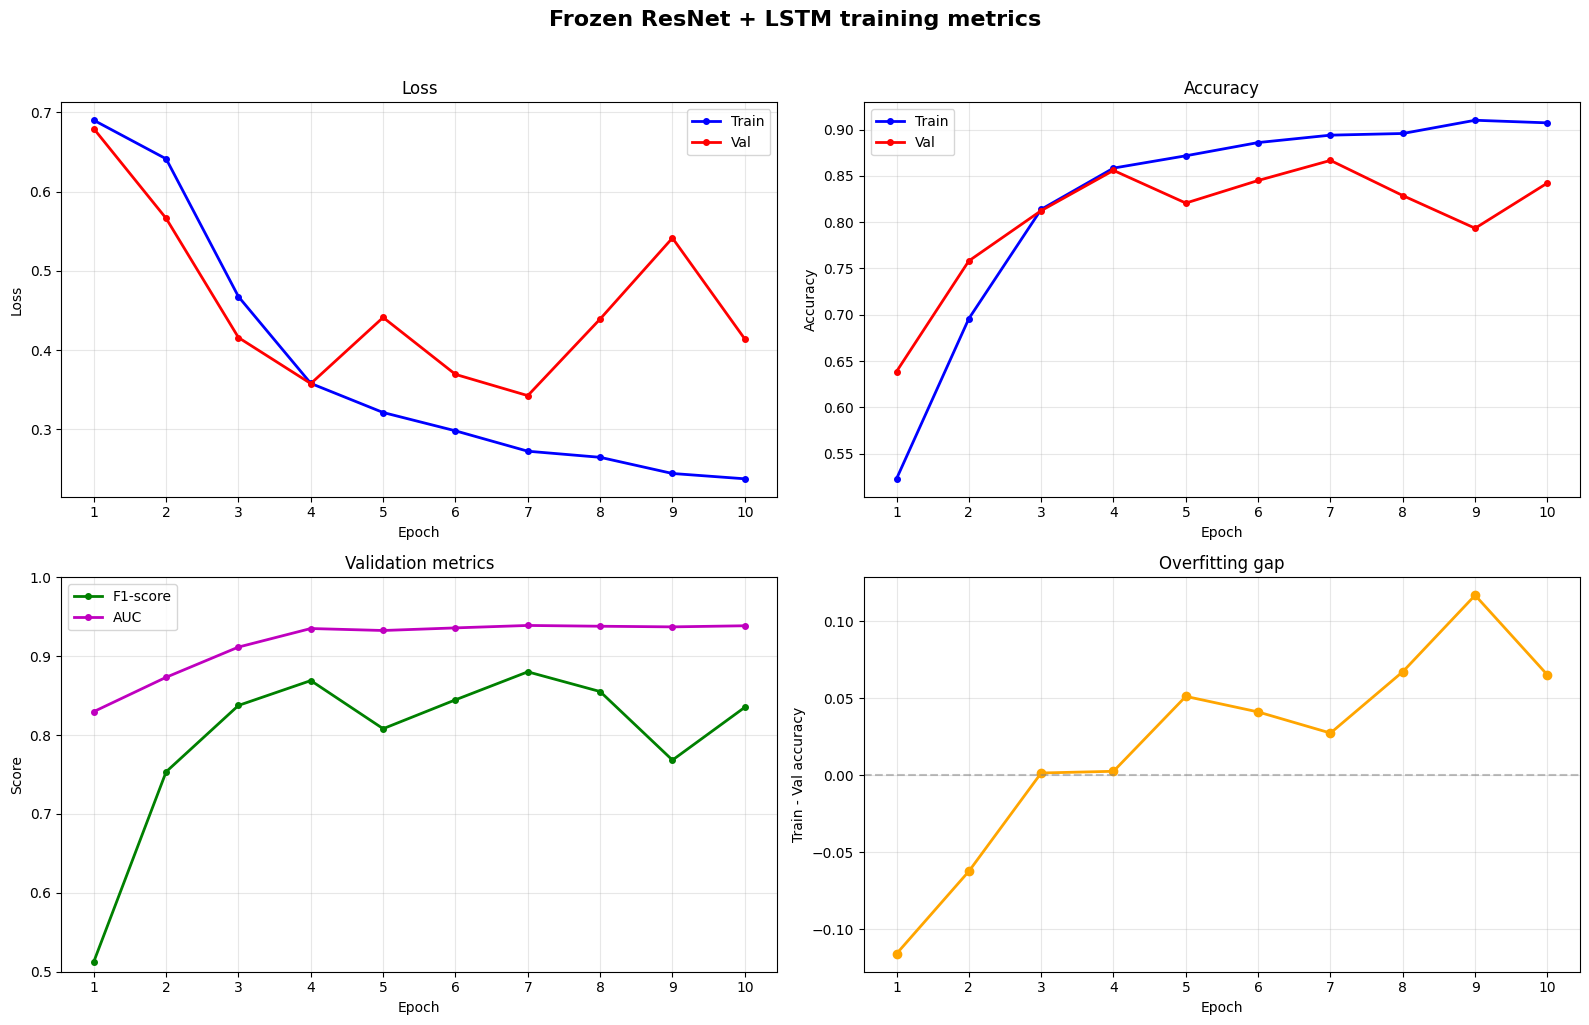


 Final metrics (Epoch 10):
Epoch           10
Train Loss  0.2378
Train Acc   0.9074
Val Loss    0.4142
Val Acc     0.8424
Val F1      0.8352
Val AUC     0.9386

Best epoch by AUC: 7 (AUC = 0.9390)


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Данные
epochs = np.arange(1, 11)
metrics = {
    'Train Loss': train_loss_0,
    'Train Acc': train_acc_0,
    'Val Loss': vall_loss_0,
    'Val Acc': vall_acc_0,
    'Val F1': val_f1_0,
    'Val AUC': val_auc_0
}

df = pd.DataFrame(metrics, index=epochs)
df.index.name = 'Epoch'

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.plot(epochs, df['Train Loss'], 'b-o', label='Train', linewidth=2, markersize=4)
plt.plot(epochs, df['Val Loss'], 'r-o', label='Val', linewidth=2, markersize=4)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend(); plt.grid(alpha=0.3); plt.xticks(epochs)

plt.subplot(2, 2, 2)
plt.plot(epochs, df['Train Acc'], 'b-o', label='Train', linewidth=2, markersize=4)
plt.plot(epochs, df['Val Acc'], 'r-o', label='Val', linewidth=2, markersize=4)
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.legend(); plt.grid(alpha=0.3); plt.xticks(epochs)

plt.subplot(2, 2, 3)
plt.plot(epochs, df['Val F1'], 'g-o', label='F1-score', linewidth=2, markersize=4)
plt.plot(epochs, df['Val AUC'], 'm-o', label='AUC', linewidth=2, markersize=4)
plt.xlabel('Epoch'); plt.ylabel('Score'); plt.title('Validation metrics'); plt.legend(); plt.grid(alpha=0.3); plt.xticks(epochs); plt.ylim(0.5, 1.0)

plt.subplot(2, 2, 4)
gap = df['Train Acc'] - df['Val Acc']
plt.plot(epochs, gap, 'orange', marker='o', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Epoch'); plt.ylabel('Train - Val accuracy'); plt.title('Overfitting gap'); plt.grid(alpha=0.3); plt.xticks(epochs)

plt.suptitle('Frozen ResNet + LSTM training metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
print("График сохранён как 'training_metrics_frozen.png'")
plt.show()

print("\n Final metrics (Epoch 10):")
print(df.iloc[[-1]].T.round(4))

best_epoch = df['Val AUC'].idxmax()
print(f"\nBest epoch by AUC: {best_epoch} (AUC = {df.loc[best_epoch, 'Val AUC']:.4f})")

In [ ]:
import os
import shutil
from IPython.display import FileLink

folder_path = '/kaggle/working/checkpoints'
archive_path = '/kaggle/working/archived_checkpoints'

shutil.make_archive(archive_path, 'zip', folder_path)

print(f"Архив создан: {archive_path}.zip")
display(FileLink(f"{archive_path}.zip"))

In [ ]:
import os
import shutil
from IPython.display import FileLink

folder_path = '/kaggle/working/runs' 
archive_path = '/kaggle/working/archived_runs'
shutil.make_archive(archive_path, 'zip', folder_path)

print(f"Архив создан: {archive_path}.zip")
display(FileLink(f"{archive_path}.zip"))

In [32]:
model.load_state_dict(torch.load('/kaggle/working/checkpoints/model_frozen_epoch_7.pth'))
test_loss, test_acc, test_f1, test_auc = validate_epoch(model, test_loader, criterion, device)
print(f"Test Results: Loss={test_loss:.4f} Acc={test_acc:.4f} F1={test_f1:.4f} AUC={test_auc:.4f}")

Val:   0%|          | 0/58 [00:00<?, ?it/s]

Test Results: Loss=0.3564 Acc=0.8628 F1=0.8954 AUC=0.9341


In [33]:
model.load_state_dict(torch.load('/kaggle/working/checkpoints/model_frozen_epoch_4.pth'))
test_loss, test_acc, test_f1, test_auc = validate_epoch(model, test_loader, criterion, device)
print(f"Test Results: Loss={test_loss:.4f} Acc={test_acc:.4f} F1={test_f1:.4f} AUC={test_auc:.4f}")

Val:   0%|          | 0/58 [00:00<?, ?it/s]

Test Results: Loss=0.3547 Acc=0.8514 F1=0.8848 AUC=0.9368


In [29]:
print(val_loss, val_acc, val_f1, val_auc)

0.5458172713888103 0.7974068071312804 0.8259860788863109 0.939451105782041


# Разморозка слоев ResNet

In [7]:
class ResNetLSTM(nn.Module):
    def __init__(self, lstm_hidden=256, lstm_layers=2, dropout=0.5, 
                 freeze_cnn=True, unfreeze_layers=0):
        super().__init__()

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        self.layer1 = resnet.layer1  
        self.layer2 = resnet.layer2  
        self.layer3 = resnet.layer3  
        self.layer4 = resnet.layer4 
        
        self.avgpool = resnet.avgpool

        self.cnn_layers = [self.layer1, self.layer2, self.layer3, self.layer4]
        
        self.cnn_out_dim = 2048

        if freeze_cnn:
            for param in self.conv1.parameters():
                param.requires_grad = False
            for param in self.bn1.parameters():
                param.requires_grad = False
            for layer in self.cnn_layers:
                for param in layer.parameters():
                    param.requires_grad = False

        if unfreeze_layers > 0:
            layers_to_unfreeze = self.cnn_layers[-unfreeze_layers:]
            for i, layer in enumerate(layers_to_unfreeze):
                for param in layer.parameters():
                    param.requires_grad = True
            print(f"Разморожено слоев: {unfreeze_layers}")
            print(f" ({[f'layer{4-j}' for j in range(len(layers_to_unfreeze))][::-1]})")

        self.lstm = nn.LSTM(
            input_size=self.cnn_out_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if lstm_layers > 1 else 0
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        batch_size, frames, C, H, W = x.shape
        
        cnn_out = []
        for t in range(frames):
            frame = x[:, t, :, :, :]

            feat = self.conv1(frame)
            feat = self.bn1(feat)
            feat = self.relu(feat)
            feat = self.maxpool(feat)
            
            feat = self.layer1(feat)
            feat = self.layer2(feat)
            feat = self.layer3(feat)
            feat = self.layer4(feat)
            
            feat = self.avgpool(feat)
            feat = feat.view(batch_size, -1)
            cnn_out.append(feat)
            
        cnn_seq = torch.stack(cnn_out, dim=1)

        lstm_out, _ = self.lstm(cnn_seq)
        last_out = lstm_out[:, -1, :]
        logits = self.classifier(last_out)
        
        return logits

In [8]:
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def train_epoch_ft(model, loader, criterion, optimizer, device, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for frames, labels in tqdm(loader, desc='Train'):
        frames, labels = frames.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits = model(frames)
        loss = criterion(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        
        optimizer.step()
        
        running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    acc = accuracy_score(all_labels, all_preds)
    return running_loss / len(loader), acc

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for frames, labels in tqdm(loader, desc='Val'):
            frames, labels = frames.to(device), labels.to(device)
            logits = model(frames)
            loss = criterion(logits, labels)
            running_loss += loss.item()
            
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return running_loss / len(loader), acc, f1, auc

In [ ]:
train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = create_dataloaders(root_dir=ROOT_DIR, batch_size=16, num_workers=2, frames_per_video=16,
                                                                                                     val_max_real=None, val_max_fake=200, test_max_real=None, test_max_fake=600))

In [35]:
torch.cuda.empty_cache()

In [ ]:
import os
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter

print("Fine-tuning")

model = ResNetLSTM(lstm_hidden=256, lstm_layers=2, dropout=0.6, freeze_cnn=True, unfreeze_layers=1).to(device)

print("layer1 requires_grad:", next(model.layer1.parameters()).requires_grad)
print("layer2 requires_grad:", next(model.layer2.parameters()).requires_grad)
print("layer3 requires_grad:", next(model.layer3.parameters()).requires_grad)
print("layer4 requires_grad:", next(model.layer4.parameters()).requires_grad)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-6, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
CHECKPOINT_DIR = Path("checkpoints_finetuned")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
tb_writer = SummaryWriter(log_dir='runs/fine-tuned_cnn')

best_val_auc = 0.0
train_loss_1, train_acc_1 = [], []
val_loss_1, val_acc_1, val_f1_1, val_auc_1 = [], [], [], []
EPOCHS = 10

for epoch in range(EPOCHS):
    torch.cuda.empty_cache()
    train_loss, train_acc = train_epoch_ft(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, val_auc = validate_epoch(model, val_loader, criterion, device)
    
    train_loss_1.append(round(train_loss, 4)); train_acc_1.append(round(train_acc, 4))
    val_loss_1.append(round(val_loss, 4)); val_acc_1.append(round(val_acc, 4))
    val_f1_1.append(round(val_f1, 4)); val_auc_1.append(round(val_auc, 4))
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    tb_writer.add_scalar('Stage2/Loss/Train', train_loss, epoch+1)
    tb_writer.add_scalar('Stage2/Accuracy/Train', train_acc, epoch+1)
    tb_writer.add_scalar('Stage2/Learning_Rate', current_lr, epoch+1)
    tb_writer.add_scalar('Stage2/Loss/Val', val_loss, epoch+1)
    tb_writer.add_scalar('Stage2/Accuracy/Val', val_acc, epoch+1)
    tb_writer.add_scalar('Stage2/F1/Val', val_f1, epoch+1)
    tb_writer.add_scalar('Stage2/AUC/Val', val_auc, epoch+1)

    print(f"Epoch {epoch+1}: Train loss={train_loss:.4f}, Acc={train_acc:.4f}, "
          f"Val loss={val_loss:.4f}, Acc={val_acc:.4f}, F1={val_f1:.4f}, AUC={val_auc:.4f}")
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), CHECKPOINT_DIR / "best_model_fine-tuned.pth")
        
    torch.save(model.state_dict(), CHECKPOINT_DIR / f"model_fine-tuned_epoch_{epoch+1}.pth")

tb_writer.close()
print("Логи сохранены в папку `runs/fine-tuned_cnn`")

# Архивирование чекпоинтов и логов тензорборда

In [ ]:
import os
import shutil
from IPython.display import FileLink

folder_path = '/kaggle/working/checkpoints_finetuned' 

archive_path = '/kaggle/working/archived_checkpoints_finetuned'

shutil.make_archive(archive_path, 'zip', folder_path)
print(f"Архив создан: {archive_path}.zip")

display(FileLink(f"{archive_path}.zip"))

In [ ]:
folder_path = '/kaggle/working/runs'

archive_path = '/kaggle/working/archived_runs'

shutil.make_archive(archive_path, 'zip', folder_path)
print(f"Архив создан: {archive_path}.zip")

display(FileLink(f"{archive_path}.zip"))

In [ ]:
model.load_state_dict(torch.load('/kaggle/working/checkpoints_finetuned/model_fine-tuned_epoch_7.pth'))
test_loss, test_acc, test_f1, test_auc = validate_epoch(model, test_loader, criterion, device)
print(f"Test Results: Loss={test_loss:.4f} Acc={test_acc:.4f} F1={test_f1:.4f} AUC={test_auc:.4f}")

In [23]:
torch.cuda.empty_cache()

# Визуализация графиков обучения (с размороженными слоями)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Данные
epochs = np.arange(1, 11)
metrics = {
    'Train Loss': train_loss_1,
    'Train Acc': train_acc_1,
    'Val Loss': val_loss_1,
    'Val Acc':  val_acc_1,
    'Val F1': val_f1_1,
    'Val AUC': val_auc_1
}

df = pd.DataFrame(metrics, index=epochs)
df.index.name = 'Epoch'

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.plot(epochs, df['Train Loss'], 'b-o', label='Train', linewidth=2, markersize=4)
plt.plot(epochs, df['Val Loss'], 'r-o', label='Val', linewidth=2, markersize=4)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend(); plt.grid(alpha=0.3); plt.xticks(epochs)

plt.subplot(2, 2, 2)
plt.plot(epochs, df['Train Acc'], 'b-o', label='Train', linewidth=2, markersize=4)
plt.plot(epochs, df['Val Acc'], 'r-o', label='Val', linewidth=2, markersize=4)
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.legend(); plt.grid(alpha=0.3); plt.xticks(epochs)

plt.subplot(2, 2, 3)
plt.plot(epochs, df['Val F1'], 'g-o', label='F1-score', linewidth=2, markersize=4)
plt.plot(epochs, df['Val AUC'], 'm-o', label='AUC', linewidth=2, markersize=4)
plt.xlabel('Epoch'); plt.ylabel('Score'); plt.title('Validation metrics'); plt.legend(); plt.grid(alpha=0.3); plt.xticks(epochs); plt.ylim(0.5, 1.0)

plt.subplot(2, 2, 4)
gap = df['Train Acc'] - df['Val Acc']
plt.plot(epochs, gap, 'orange', marker='o', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Epoch'); plt.ylabel('Train - Val accuracy'); plt.title('Overfitting gap'); plt.grid(alpha=0.3); plt.xticks(epochs)

plt.suptitle('Fine-tuned ResNet + LSTM training metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
print("График сохранён как 'training_metrics.png'")
plt.show()

print("\n Final metrics (Epoch 10):")
print(df.iloc[[-1]].T.round(4))

best_epoch = df['Val AUC'].idxmax()
print(f"\nBest epoch by AUC: {best_epoch} (AUC = {df.loc[best_epoch, 'Val AUC']:.4f})")

# Тестирование на датасете хуавея


In [2]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import numpy as np
from pathlib import Path

class HuaweiTestDataset(Dataset):
    def __init__(self, csv_path, frames_root, num_frames=16, transform=None):
        self.df = pd.read_csv(csv_path)
        self.frames_root = Path(frames_root)
        self.num_frames = num_frames
        self.transform = transform
        
        self.video_data = []
        
        for _, row in self.df.iterrows():
            obj_id = str(row['obj_id'])
            label = int(row['label']) if not pd.isna(row['label']) else -1
            
            video_dir = self.frames_root / obj_id
            if video_dir.exists():
                frames = list(video_dir.glob('*.jpg')) + list(video_dir.glob('*.png'))
                frames = sorted(frames, key=lambda x: int(x.stem) if x.stem.isdigit() else 0)
                
                if len(frames) > 0:
                    self.video_data.append({
                        'obj_id': obj_id,
                        'label': label,
                        'frames': frames
                    })
        
        print(f"Найдено {len(self.video_data)} видео для обработки.")

    def __len__(self):
        return len(self.video_data)

    def __getitem__(self, idx):
        item = self.video_data[idx]
        frames_paths = item['frames']

        final_frames = []
        
        if len(frames_paths) >= self.num_frames:
            indices = np.linspace(0, len(frames_paths) - 1, self.num_frames, dtype=int)
            selected_paths = [frames_paths[i] for i in indices]
            final_frames = selected_paths
        else:
            final_frames = list(frames_paths)
            padding_needed = self.num_frames - len(final_frames)
            last_frame = final_frames[-1]
            final_frames.extend([last_frame] * padding_needed)

        frames_tensor = []
        for f_path in final_frames:
            img = Image.open(f_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            frames_tensor.append(img)
            
        frames_tensor = torch.stack(frames_tensor)
        
        return frames_tensor, item['label'] 

def get_test_transforms():
    return T.Compose([
        T.Resize(224),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def create_test_dataloader(
    csv_path='/kaggle/input/datasets/mariaspasyuk/huawei-test/d83a0ce6-dc87-46a6-9679-98a71cf91886.csv',
    frames_root='/kaggle/input/datasets/mariaspasyuk/hweidatasetfaces/hweiDatasetFaces',
    num_frames=16,
    batch_size=8,
    num_workers=2
):
    dataset = HuaweiTestDataset(
        csv_path=csv_path,
        frames_root=frames_root,
        num_frames=num_frames,
        transform=get_test_transforms()
    )
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=True
    )
    
    return dataset, dataloader

hw_dataset, hw_dataloader = create_test_dataloader()

Найдено 45 видео для обработки.


In [11]:
print("Testing best frozen model")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
model = ResNetLSTM(freeze_cnn=True).to(device)
model.load_state_dict(torch.load('/kaggle/working/checkpoints/model_frozen_epoch_4.pth'))
hw_test_loss, hw_test_acc, hw_test_f1, hw_test_auc = validate_epoch(model, hw_dataloader, criterion, device)
print(f"Test Results: Loss={hw_test_loss:.4f} Acc={hw_test_acc:.4f} F1={hw_test_f1:.4f} AUC={hw_test_auc:.4f}")


=== Testing best model ===


Val:   0%|          | 0/6 [00:00<?, ?it/s]

Test Results: Loss=0.7548 Acc=0.6889 F1=0.7500 AUC=0.7112


In [ ]:
print("Testing best fine-tuned model")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
model.load_state_dict(torch.load('/kaggle/working/checkpoints_finetuned/model_fine-tuned_epoch_7.pth'))
hw_test_loss, hw_test_acc, hw_test_f1, hw_test_auc = validate_epoch(model, hw_dataloader, criterion, device)
print(f"Test Results: Loss={hw_test_loss:.4f} Acc={hw_test_acc:.4f} F1={hw_test_f1:.4f} AUC={hw_test_auc:.4f}")